# ML Work

## Predicting Ages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/titanic_eda.csv')
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,total_fare,Embarked,lone_traveler,surname,family_size,fare_per_person
0,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,No,Braund,2,3.625000
1,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,No,Cumings,2,35.641650
2,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Yes,Heikkinen,1,7.925000
3,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,No,Futrelle,2,26.550000
4,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Yes,Allen,1,8.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,S,Yes,Spector,1,8.050000
1305,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,Yes,Oliva y Ocana,1,108.900000
1306,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S,Yes,Saether,1,7.250000
1307,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,S,Yes,Ware,1,8.050000


Importing issential libraries for ML

In [3]:

from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, r2_score, mean_absolute_error, root_mean_squared_error, roc_auc_score, roc_curve
from sklearn.metrics import ConfusionMatrixDisplay 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV      
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [4]:
df_train = df.copy()

In [5]:
df_train['Embarked_S'] = df_train['Embarked'].apply(lambda x: 1 if x == 'S' else 0)
df_train['Embarked_C'] = df_train['Embarked'].apply(lambda x: 1 if x == 'C' else 0)
df_train['Embarked_Q'] = df_train['Embarked'].apply(lambda x: 1 if x == 'Q' else 0)
df_train['lone_traveler'] = df_train['lone_traveler'].apply(lambda x: 1 if x == 'Yes' else 0)
df_train['Sex'] = df_train['Sex'].replace({'male': 0, 'female': 1})

df_train = df_train.drop(columns=['Name', 'Ticket', 'surname', 'Embarked'])


df_train

,Survived,Pclass,Sex,Age,SibSp,Parch,total_fare,lone_traveler,family_size,fare_per_person,Embarked_S,Embarked_C,Embarked_Q
0,0.0,3,0,22.0,1,0,7.2500,0,2,3.625000,1,0,0
1,1.0,1,1,38.0,1,0,71.2833,0,2,35.641650,0,1,0
2,1.0,3,1,26.0,0,0,7.9250,1,1,7.925000,1,0,0
3,1.0,1,1,35.0,1,0,53.1000,0,2,26.550000,1,0,0
4,0.0,3,0,35.0,0,0,8.0500,1,1,8.050000,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,NaN,3,0,NaN,0,0,8.0500,1,1,8.050000,1,0,0
1305,NaN,1,1,39.0,0,0,108.9000,1,1,108.900000,0,1,0
1306,NaN,3,0,38.5,0,0,7.2500,1,1,7.250000,1,0,0
1307,NaN,3,0,NaN,0,0,8.0500,1,1,8.050000,1,0,0


In [6]:
#X = df_train.drop(columns=['Age'])
#y = df_train['Age']

with_age = df_train[df_train['Age'].notna()]
without_age = df_train[df_train['Age'].isna()]
feature_cols = [c for c in df_train.columns if c not in ['Age', 'Survived']]
X = with_age[feature_cols]
y = with_age['Age']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42    
)


In [8]:
y_test

961     24.0
348      3.0
789     46.0
396     31.0
1263    49.0
        ... 
856     45.0
775     18.0
399     28.0
1262    31.0
487     58.0
Name: Age, Length: 210, dtype: float64

In [9]:
param_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

In [10]:
pipe1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),   
    ('model' ,  Ridge())    
])

In [11]:
grid = GridSearchCV(pipe1,param_grid, cv=5)
grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

In [12]:
best_alpha = grid.best_params_['model__alpha']
print(f"Best alpha: {best_alpha}")

Best alpha: 10.0


In [13]:
y_pred_lr = grid.predict(X_test)   

In [14]:
mae = mean_absolute_error(y_test,y_pred_lr )
mae

9.082154176469437

In [15]:
r2 = r2_score(y_test,y_pred_lr)
r2

0.18992348717147056

In [16]:
rmse = root_mean_squared_error(y_test,y_pred_lr)
rmse

11.602170998983992

In [17]:
train_score = grid.score(X_train, y_train)
test_score = grid.score(X_test, y_test)

print("Train:", train_score)
print("Test:", test_score)

Train: 0.23997957300409145
Test: 0.18992348717147056


In [18]:
pipe2 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),   
    ('sgdr' ,SGDRegressor(
        penalty='l2', max_iter=1000,l1_ratio=0.15
    ))    
])

In [19]:
param_grid = {
    'sgdr__learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'sgdr__alpha': [0.001, 0.01, 0.1, 1.0]
}

In [20]:
grid_sgd = GridSearchCV(pipe2, param_grid, cv=5)
grid_sgd.fit(X_train , y_train )

c:\Users\ASUS\OneDrive\Documents\Tiatanic-PD-Project\venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\ASUS\OneDrive\Documents\Tiatanic-PD-Project\venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\ASUS\OneDrive\Documents\Tiatanic-PD-Project\venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'sgdr__alpha': [0.001, 0.01, ...], 'sgdr__learning_rate': ['constant', 'optimal', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

In [21]:
y_pred_sgdr = grid_sgd.predict(X_test)

In [22]:
mae = mean_absolute_error(y_test,y_pred_sgdr )
mae

9.086039144765232

In [23]:
r2 = r2_score(y_test,y_pred_sgdr)
r2

0.18929067689105072

In [24]:
rmse = root_mean_squared_error(y_test,y_pred_sgdr)
rmse

11.606701768416396

In [25]:
print("Train:", grid_sgd.score(X_train, y_train))
print("Test:", grid_sgd.score(X_test, y_test))

Train: 0.24001007622477977
Test: 0.18929067689105072


In [26]:
results = {
    "Ridge": {
        "MAE" : mean_absolute_error(y_test, y_pred_lr),
        "RMSE": root_mean_squared_error(y_test, y_pred_lr),
        "R2"  : r2_score(y_test, y_pred_lr),
        "Train R2": grid.score(X_train, y_train),
        "Test R2" : grid.score(X_test,  y_test),
    },
    "SGDRegressor": {
        "MAE" : mean_absolute_error(y_test, y_pred_sgdr),
        "RMSE": root_mean_squared_error(y_test, y_pred_sgdr),
        "R2"  : r2_score(y_test, y_pred_sgdr),
        "Train R2": grid_sgd.score(X_train, y_train),
        "Test R2" : grid_sgd.score(X_test,  y_test),
    },
}

results_df = pd.DataFrame(results).T.round(4)

results_df

,MAE,RMSE,R2,Train R2,Test R2
Ridge,9.0822,11.6022,0.1899,0.24,0.1899
SGDRegressor,9.0860,11.6067,0.1893,0.24,0.1893


In [27]:
best_model_name =results_df['R2'].idxmax()
best_model = grid if best_model_name == "Ridge" else grid_sgd
print(f"Best model: {best_model_name}")

Best model: Ridge


In [28]:
X_missing = without_age[feature_cols]
print("X_missing rows  :", len(X_missing))     

predicted_ages = best_model.predict(X_missing)
print("Predictions made:", len(predicted_ages))


X_missing rows  : 263
Predictions made: 263


- As we can see here our R2 score is not that good cause we dont have enough features to predicit AGE but this pridictions are better than using mean 


In [29]:
without_age['Age'] = predicted_ages

In [30]:
df['Age'] = df_train['Age'].fillna(without_age['Age'])   

In [31]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,total_fare,Embarked,lone_traveler,surname,family_size,fare_per_person
0,0.0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S,No,Braund,2,3.625000
1,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C,No,Cumings,2,35.641650
2,1.0,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S,Yes,Heikkinen,1,7.925000
3,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S,No,Futrelle,2,26.550000
4,0.0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S,Yes,Allen,1,8.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,NaN,3,"Spector, Mr. Woolf",male,27.981059,0,0,A.5. 3236,8.0500,S,Yes,Spector,1,8.050000
1305,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.000000,0,0,PC 17758,108.9000,C,Yes,Oliva y Ocana,1,108.900000
1306,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.500000,0,0,SOTON/O.Q. 3101262,7.2500,S,Yes,Saether,1,7.250000
1307,NaN,3,"Ware, Mr. Frederick",male,27.981059,0,0,359309,8.0500,S,Yes,Ware,1,8.050000


In [32]:
df_train

,Survived,Pclass,Sex,Age,SibSp,Parch,total_fare,lone_traveler,family_size,fare_per_person,Embarked_S,Embarked_C,Embarked_Q
0,0.0,3,0,22.0,1,0,7.2500,0,2,3.625000,1,0,0
1,1.0,1,1,38.0,1,0,71.2833,0,2,35.641650,0,1,0
2,1.0,3,1,26.0,0,0,7.9250,1,1,7.925000,1,0,0
3,1.0,1,1,35.0,1,0,53.1000,0,2,26.550000,1,0,0
4,0.0,3,0,35.0,0,0,8.0500,1,1,8.050000,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,NaN,3,0,NaN,0,0,8.0500,1,1,8.050000,1,0,0
1305,NaN,1,1,39.0,0,0,108.9000,1,1,108.900000,0,1,0
1306,NaN,3,0,38.5,0,0,7.2500,1,1,7.250000,1,0,0
1307,NaN,3,0,NaN,0,0,8.0500,1,1,8.050000,1,0,0


## Pridicting Survived

In [33]:
train = df_train[df_train['Survived'].notna()]  
test  = df_train[df_train['Survived'].isna()] 

X = train.drop(columns=['Survived'])
y = train['Survived']

In [34]:
X

,Pclass,Sex,Age,SibSp,Parch,total_fare,lone_traveler,family_size,fare_per_person,Embarked_S,Embarked_C,Embarked_Q
0,3,0,22.0,1,0,7.2500,0,2,3.62500,1,0,0
1,1,1,38.0,1,0,71.2833,0,2,35.64165,0,1,0
2,3,1,26.0,0,0,7.9250,1,1,7.92500,1,0,0
3,1,1,35.0,1,0,53.1000,0,2,26.55000,1,0,0
4,3,0,35.0,0,0,8.0500,1,1,8.05000,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,0,27.0,0,0,13.0000,1,1,13.00000,1,0,0
887,1,1,19.0,0,0,30.0000,1,1,30.00000,1,0,0
888,3,1,NaN,1,2,23.4500,0,4,5.86250,1,0,0
889,1,0,26.0,0,0,30.0000,1,1,30.00000,0,1,0


In [35]:
y

0      0.0
1      1.0
2      1.0
3      1.0
4      0.0
      ... 
886    0.0
887    1.0
888    0.0
889    1.0
890    0.0
Name: Survived, Length: 891, dtype: float64

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
X_train

,Pclass,Sex,Age,SibSp,Parch,total_fare,lone_traveler,family_size,fare_per_person,Embarked_S,Embarked_C,Embarked_Q
331,1,0,45.5,0,0,28.5000,1,1,28.500000,1,0,0
733,2,0,23.0,0,0,13.0000,1,1,13.000000,1,0,0
382,3,0,32.0,0,0,7.9250,1,1,7.925000,1,0,0
704,3,0,26.0,1,0,7.8542,0,2,3.927100,1,0,0
813,3,1,6.0,4,2,31.2750,0,7,4.467857,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
106,3,1,21.0,0,0,7.6500,1,1,7.650000,1,0,0
270,1,0,NaN,0,0,31.0000,1,1,31.000000,1,0,0
860,3,0,41.0,2,0,14.1083,0,3,4.702767,1,0,0
435,1,1,14.0,1,2,120.0000,0,4,30.000000,1,0,0


In [38]:
X_test

,Pclass,Sex,Age,SibSp,Parch,total_fare,lone_traveler,family_size,fare_per_person,Embarked_S,Embarked_C,Embarked_Q
709,3,0,NaN,1,1,15.2458,0,3,5.081933,0,1,0
439,2,0,31.0,0,0,10.5000,1,1,10.500000,1,0,0
840,3,0,20.0,0,0,7.9250,1,1,7.925000,1,0,0
720,2,1,6.0,0,1,33.0000,0,2,16.500000,1,0,0
39,3,1,14.0,1,0,11.2417,0,2,5.620850,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
433,3,0,17.0,0,0,7.1250,1,1,7.125000,1,0,0
773,3,0,NaN,0,0,7.2250,1,1,7.225000,0,1,0
25,3,1,38.0,1,5,31.3875,0,7,4.483929,1,0,0
84,2,1,17.0,0,0,10.5000,1,1,10.500000,1,0,0


In [39]:
y_train

331    0.0
733    0.0
382    0.0
704    0.0
813    0.0
      ... 
106    1.0
270    0.0
860    0.0
435    1.0
102    0.0
Name: Survived, Length: 712, dtype: float64

In [40]:
y_test

709    1.0
439    0.0
840    0.0
720    1.0
39     1.0
      ... 
433    0.0
773    0.0
25     1.0
84     1.0
10     1.0
Name: Survived, Length: 179, dtype: float64

In [41]:
pipe3 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),   
    ('model' ,  LogisticRegression())
])

In [42]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver' : ['lbfgs' , 'liblinear', 'saga' ]
}

In [43]:
grid_lr = GridSearchCV(pipe3, param_grid, cv=5, scoring='roc_auc')

In [44]:
grid_lr.fit(X_train,y_train)

c:\Users\ASUS\OneDrive\Documents\Tiatanic-PD-Project\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\ASUS\OneDrive\Documents\Tiatanic-PD-Project\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\ASUS\OneDrive\Documents\Tiatanic-PD-Project\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\ASUS\OneDrive\Documents\Tiatanic-PD-Project\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__solver': ['lbfgs', 'liblinear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [45]:
print("Best params:", grid_lr.best_params_)
print("Best AUC:", grid_lr.best_score_)

Best params: {'model__C': 0.1, 'model__solver': 'lbfgs'}
Best AUC: 0.8430536372130607


In [46]:
y_pred = grid_lr.predict(X_test)
y_pred

array([0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
       1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1.,
       0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
       1., 0., 0., 0., 1., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0.,
       0., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1.,
       0., 0., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 1.,
       1., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0.,
       1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
       1., 1., 0., 1., 0., 0., 0., 1., 1.])

In [47]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7932960893854749


In [48]:
class_report = classification_report(y_test, y_pred)
print(class_report)

              precision    recall  f1-score   support

         0.0       0.80      0.86      0.83       105
         1.0       0.78      0.70      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [49]:
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[90 15]
 [22 52]]


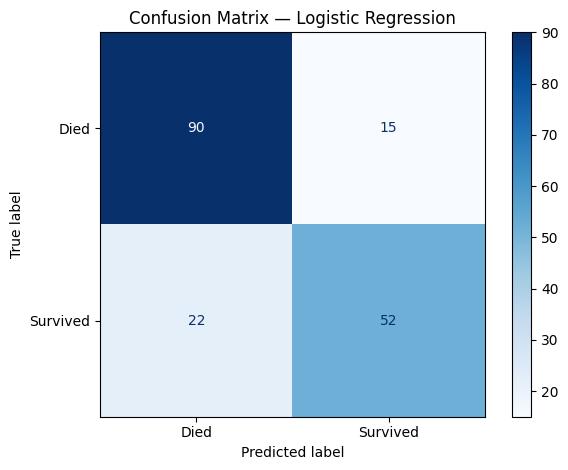

In [50]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Died', 'Survived'],
    cmap='Blues'
)
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

ROC Curve for Logistic Regression

In [51]:
y_prob_lr = grid_lr.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc = roc_auc_score(y_test, y_prob_lr)
print("AUC:", auc)

AUC: 0.8854568854568854


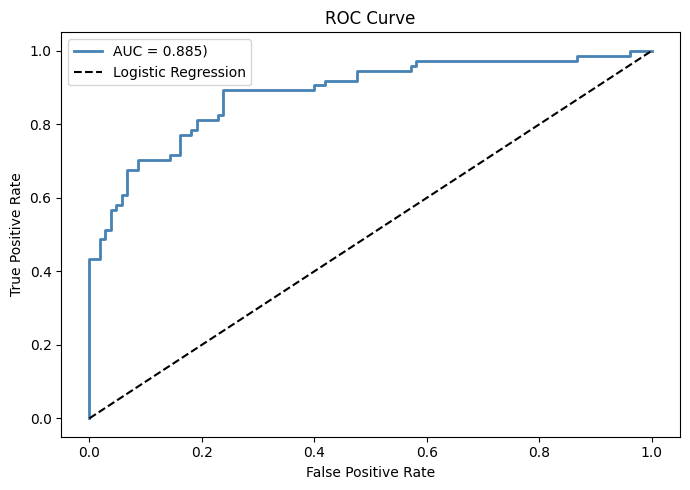

In [52]:
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

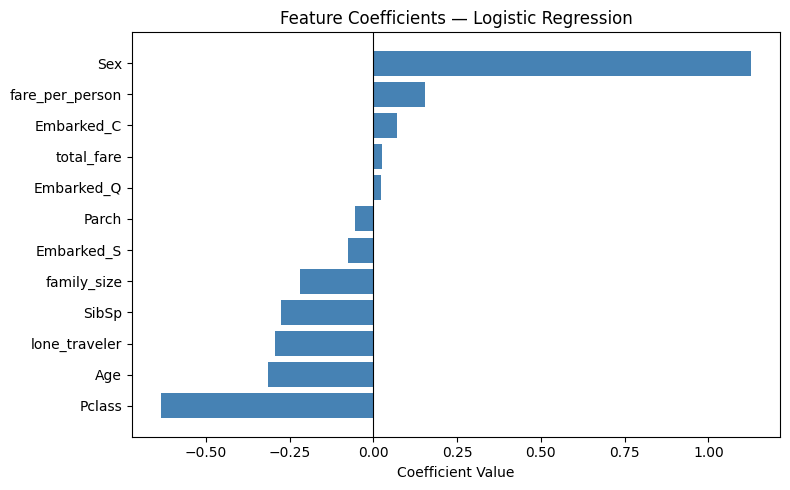

In [53]:
model = grid_lr.best_estimator_.named_steps['model']
feature_names = X_train.columns.tolist()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient')

plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Logistic Regression')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [54]:
pipe4 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier( random_state=42))
])

In [55]:
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features': ['sqrt', 'log2']
}

In [56]:
grid_rf = GridSearchCV(pipe4, param_grid, cv=5, scoring='roc_auc')

In [57]:
grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [3, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comput

In [58]:
print("Best params:", grid_rf.best_params_)
print("Best AUC:", grid_rf.best_score_)

Best params: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best AUC: 0.8614000581034713


In [59]:
y_pred_rf = grid_rf.predict(X_test)

In [60]:
class_report = classification_report(y_test, y_pred_rf)
print(class_report)

              precision    recall  f1-score   support

         0.0       0.80      0.90      0.85       105
         1.0       0.82      0.69      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



In [61]:
conf_matrix = confusion_matrix(y_test, y_pred_rf)
print(conf_matrix)

[[94 11]
 [23 51]]


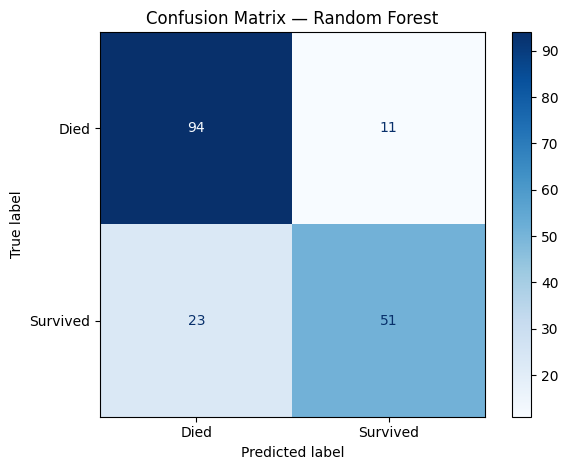

In [62]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Died', 'Survived'],
    cmap='Blues'
)
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

- ROC Curve for Random Forest

In [63]:
y_prob_rf = grid_rf.predict_proba(X_test)[:, 1]
fpr,tpr, _ = roc_curve(y_test, y_prob_rf)
auc = roc_auc_score(y_test, y_prob_rf)
print("AUC:", auc)

AUC: 0.8943371943371943


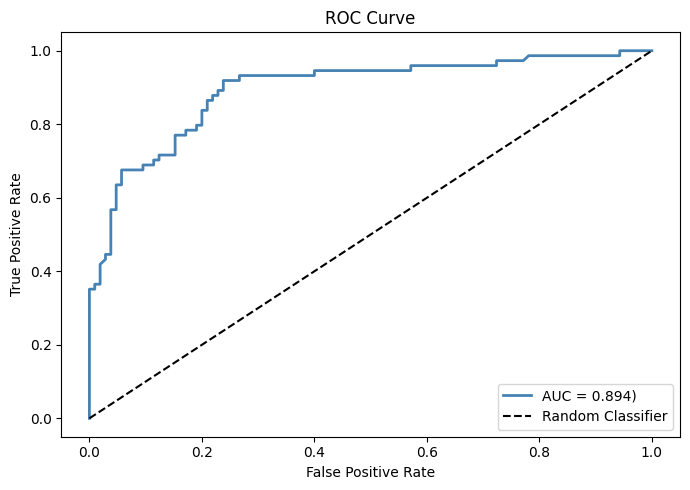

In [64]:
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

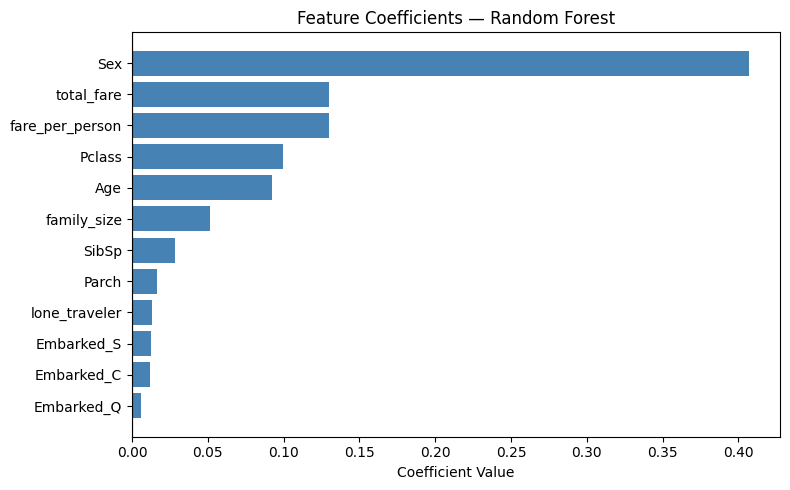

In [65]:
model = grid_rf.best_estimator_.named_steps['model']
feature_names = X_train.columns.tolist()
Importance = model.feature_importances_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': Importance
}).sort_values('Coefficient')

plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Random Forest')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()